# B1 — Network Characterization

Structural analysis of $G_{BC}$ (combined: citation + bibliographic coupling) and $G_{Cit}$ (citation only).  
All heavy computations (paths, centralities) are cached to CSV on first run.

In [ ]:
import os, gc, time, pickle
from collections import Counter
from math import log, sqrt

import networkx as nx
import networkit as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from scipy.stats import spearmanr, poisson
from pathlib import Path


In [2]:
BASE_DIR = Path().resolve().parent.parent
GRAPH_DIR = BASE_DIR / "data" / "graph"
out_dir   = "./output"

plt.rcParams.update({
    'figure.dpi': 150, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25,
})
COLORS = {'bc': 'tab:blue', 'cit': 'tab:orange', 'cit_d': 'darkorange'}
NAMES  = {'bc': 'Combined', 'cit': 'Citation'}

## Helpers

In [ ]:
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def make_unweighted(G: nx.Graph) -> nx.Graph:
    H = nx.Graph()
    H.add_nodes_from(G.nodes(data=True))
    H.add_edges_from(G.edges())
    return H

def extract_lcc(G):
    fn = nx.weakly_connected_components if G.is_directed() else nx.connected_components
    return G.subgraph(max(fn(G), key=len)).copy()

def ccdf(arr):
    s = np.sort(arr[arr > 0])[::-1]
    return s, np.arange(1, len(s) + 1) / len(arr)

def style_ax(ax, logx=False, logy=False):
    ax.grid(True, which='major', ls='-',  lw=0.5, alpha=0.35, color='gray')
    ax.grid(True, which='minor', ls='--', lw=0.3, alpha=0.20, color='gray')
    ax.minorticks_on()
    fmt = ticker.LogFormatterSciNotation(labelOnlyBase=False)
    if logx: ax.xaxis.set_major_formatter(fmt)
    if logy: ax.yaxis.set_major_formatter(fmt)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

def stat_row(arr):
    return {
        'Mean': np.mean(arr), 'Std': np.std(arr), 'Median': np.median(arr),
        'Max': np.max(arr),
        'P90': np.percentile(arr, 90), 'P99': np.percentile(arr, 99),
    }

def cent_row(d):
    v = np.fromiter(d.values(), dtype=float)
    m = v.mean()
    return {'Mean': m, 'Std': v.std(), 'Max': v.max(),
            'P99': float(np.percentile(v, 99)),
            '>μ+2σ': int((v > m + 2 * v.std()).sum())}

#  NetworKit bridge 
def nx_to_nk(G_nx):
    nodes = list(G_nx.nodes())
    nx2nk = {n: i for i, n in enumerate(nodes)}
    G_nk  = nk.Graph(len(nodes), weighted=False, directed=False)
    for u, v in G_nx.edges():
        G_nk.addEdge(nx2nk[u], nx2nk[v])
    return G_nk, {i: n for n, i in nx2nk.items()}

def run_centrality(G_nk, nk2nx, build_fn, label):
    t0 = time.time()
    algo = build_fn(G_nk); algo.run(); s = algo.scores()
    print(f"  [{label}] {time.time()-t0:.1f}s")
    return {nk2nx[i]: s[i] for i in range(len(s))}

#  Centrality cache 
def save_cent(d1, d2, path):
    pd.DataFrame(
        [{'node': n, 'graph': 'bc',  'value': v} for n, v in d1.items()]
      + [{'node': n, 'graph': 'cit', 'value': v} for n, v in d2.items()]
    ).to_csv(path, index=False)

def load_cent(path):
    df = pd.read_csv(path)
    return {g: dict(zip(gr['node'], gr['value'])) for g, gr in df.groupby('graph')}

def load_or_compute_cent(cache, compute_fn, label):
    if os.path.exists(cache):
        print(f"{label}: cache hit")
        c = load_cent(cache)
        return c['bc'], c['cit']
    print(f"Computing {label} ...")
    bc, cit = compute_fn()
    save_cent(bc, cit, cache)
    return bc, cit

## 1 Load & Overview

In [ ]:
G_combined_w  = load_pickle(os.path.join(GRAPH_DIR, "graph_combined_2020.gpickle"))
G_cit_d       = load_pickle(os.path.join(GRAPH_DIR, "graph_internal_2020.gpickle"))
G_combined_uw = make_unweighted(G_combined_w)
G_cit_ud      = G_cit_d.to_undirected()

graphs_full = {'bc': G_combined_uw, 'cit': G_cit_ud}
lcc = {k: extract_lcc(G) for k, G in graphs_full.items()}

#  Overview table (→ Table 1) 
rows = []
for k, G in graphs_full.items():
    n, m = G.number_of_nodes(), G.number_of_edges()
    cc = nx.number_connected_components(G)
    L  = lcc[k]
    nl, ml = L.number_of_nodes(), L.number_of_edges()
    rows.append({'Graph': NAMES[k], 'N': n, 'M': m, 'CC': cc,
                 'N_lcc': nl, 'M_lcc': ml, 'Cov (%)': round(nl / n * 100, 1)})

df_overview = pd.DataFrame(rows).set_index('Graph')
print(df_overview.to_string())

              N       M    CC  N_lcc   M_lcc  Cov (%)
Graph                                                
Combined  57603  745451  1168  53405  739498     92.7
Citation  55078  217174  1488  49243  209599     89.4


## 2 Edge Composition

In [5]:
# Classify edges by signal type
is_direct = np.array([bool(d.get('is_direct', False)) for *_, d in G_combined_w.edges(data=True)])
has_bc    = np.array([d.get('bc', 0) > 0              for *_, d in G_combined_w.edges(data=True)])

m_cit  = is_direct & ~has_bc
m_bc   = ~is_direct
m_both = is_direct &  has_bc
n_total = len(is_direct)

for label, mask in [('Direct only', m_cit), ('BC only', m_bc), ('Both', m_both)]:
    n = mask.sum()
    print(f"  {label:<13}: {n:>10,}  ({n/n_total*100:.1f}%)")

print(f"\nBC contributes {m_bc.sum() / m_cit.sum():.2f}x as many edges as direct citation")

  Direct only  :    145,030  (19.5%)
  BC only      :    528,277  (70.9%)
  Both         :     72,144  (9.7%)

BC contributes 3.64x as many edges as direct citation


## 3 Degree Distribution

In [6]:
deg = {k: np.array([d for _, d in lcc[k].degree()]) for k in ('bc', 'cit')}

df_deg = pd.DataFrame({NAMES[k]: stat_row(v) for k, v in deg.items()}).T
df_deg['k=1 (%)'] = [round(np.mean(v == 1) * 100, 1) for v in deg.values()]
print(df_deg.to_string(float_format=lambda x: f'{x:.2f}'))

          Mean    Std  Median     Max   P90    P99  k=1 (%)
Combined 27.69 103.21    8.00 1169.00 30.00 726.00     7.80
Citation  8.51  10.78    6.00  621.00 18.00  41.00    10.40


## 4 Clustering & Density

In [7]:
print("Computing clustering coefficients ...")
clust = {k: np.fromiter(nx.clustering(lcc[k]).values(), dtype=float) for k in ('bc', 'cit')}
dens  = {k: nx.density(lcc[k]) for k in ('bc', 'cit')}

rows = []
for k in ('bc', 'cit'):
    v = clust[k]
    rows.append({'Graph': NAMES[k], 'Avg C': v.mean(), 'Median': np.median(v),
                 'Std': np.std(v), 'C=0 (%)': np.mean(v == 0) * 100,
                 'C=1 (%)': np.mean(v == 1) * 100, 'Density': dens[k]})

df_cl = pd.DataFrame(rows).set_index('Graph')
print(df_cl.to_string(float_format=lambda x: f'{x:.6f}'))
print(f"\nDensity ratio: {dens['bc']/dens['cit']:.2f}x   "
      f"Clustering ratio: {clust['bc'].mean()/clust['cit'].mean():.2f}x")

# Granovetter weak-tie signature (weighted vs unweighted clustering)
lcc_w = extract_lcc(G_combined_w)
c_uw = nx.clustering(lcc_w)
c_w  = nx.clustering(lcc_w, weight='weight')
common_c = list(set(c_uw) & set(c_w))
C_uw = np.mean([c_uw[n] for n in common_c])
C_w  = np.mean([c_w[n]  for n in common_c])
print(f"\nWeak-tie ratio C_w/C_uw = {C_w:.4f} / {C_uw:.4f} = {C_w/C_uw:.3f}")

Computing clustering coefficients ...
            Avg C   Median      Std   C=0 (%)  C=1 (%)  Density
Graph                                                          
Combined 0.425000 0.400000 0.284093 14.659676 6.907593 0.000519
Citation 0.342389 0.321429 0.284050 21.379688 6.756290 0.000173

Density ratio: 3.00x   Clustering ratio: 1.24x

Weak-tie ratio C_w/C_uw = 0.1782 / 0.4250 = 0.419


## 5 Path Structure

In [26]:
CACHE_PATH = os.path.join(out_dir, 'path_stats_exact.csv')
nk.setNumberOfThreads(4)

nk_graphs = {}
nk2nx_maps = {}
for k in ('bc', 'cit'):
    nk_graphs[k], nk2nx_maps[k] = nx_to_nk(lcc[k])
    print(f"  {NAMES[k]}: {nk_graphs[k].numberOfNodes():,} nodes, "
          f"{nk_graphs[k].numberOfEdges():,} edges")

def path_exact(G_nk, label, batch_size=1000):
    n = G_nk.numberOfNodes()
    sources = list(G_nk.iterNodes())
    total_sum, total_cnt, diameter = 0, 0, 0
    t0 = time.time()

    for lo in range(0, n, batch_size):
        batch = sources[lo : lo + batch_size]
        spsp = nk.distance.SPSP(G_nk, batch)
        spsp.run()

        all_dists = spsp.getDistances()
        for i, u in enumerate(batch):
            for d in all_dists[i]:
                if 0 < d < 1e15:
                    total_sum += d
                    total_cnt += 1
                    if d > diameter:
                        diameter = int(d)

    avg_path = total_sum / total_cnt if total_cnt else 0
    print(f"  [{label}] Done — L={avg_path:.4f}  diam={diameter}  "
          f"{time.time()-t0:.1f}s")
    return {'avg_path': avg_path, 'diameter': diameter}

if os.path.exists(CACHE_PATH):
    print(f"Path: cache hit ({CACHE_PATH})")
    dc = pd.read_csv(CACHE_PATH).set_index('graph')
    sp = {k: dc.loc[k].to_dict() for k in ('bc', 'cit')}
else:
    sp = {}
    for k in ('bc', 'cit'):
        sp[k] = path_exact(nk_graphs[k], NAMES[k])
    pd.DataFrame([{'graph': k, **v} for k, v in sp.items()]).to_csv(CACHE_PATH, index=False)

print(f"\nCombined: L={sp['bc']['avg_path']:.2f}  diam={int(sp['bc']['diameter'])}")
print(f"Citation: L={sp['cit']['avg_path']:.2f}  diam={int(sp['cit']['diameter'])}")
print(f"BC reduces avg path by "
      f"{(sp['cit']['avg_path']-sp['bc']['avg_path'])/sp['cit']['avg_path']*100:.1f}%")

  Combined: 53,405 nodes, 739,498 edges
  Citation: 49,243 nodes, 209,599 edges
Path: cache hit (./output/path_stats_exact.csv)

Combined: L=10.04  diam=33
Citation: L=11.81  diam=48
BC reduces avg path by 15.0%


## 6 Centrality Analysis

In [ ]:
CACHE_BETW = os.path.join(out_dir, 'betweenness_exact.csv')
CACHE_CLOS = os.path.join(out_dir, 'closeness_exact.csv')

deg_c = {k: dict(lcc[k].degree()) for k in ('bc', 'cit')}

betw_bc, betw_cit = load_or_compute_cent(CACHE_BETW, lambda: (
    run_centrality(nk_graphs['bc'],  nk2nx_maps['bc'],
                   lambda G: nk.centrality.Betweenness(G, normalized=True), 'Betw-Combined'),
    run_centrality(nk_graphs['cit'], nk2nx_maps['cit'],
                   lambda G: nk.centrality.Betweenness(G, normalized=True), 'Betw-Citation'),
), 'Betweenness')

clos_bc, clos_cit = load_or_compute_cent(CACHE_CLOS, lambda: (
    run_centrality(nk_graphs['bc'],  nk2nx_maps['bc'],
                   lambda G: nk.centrality.Closeness(G, True, nk.centrality.ClosenessVariant.STANDARD), 'Clos-Combined'),
    run_centrality(nk_graphs['cit'], nk2nx_maps['cit'],
                   lambda G: nk.centrality.Closeness(G, True, nk.centrality.ClosenessVariant.STANDARD), 'Clos-Citation'),
), 'Closeness')
betw = {'bc': betw_bc, 'cit': betw_cit}
clos = {'bc': clos_bc, 'cit': clos_cit}

# Free NetworKit objects
del nk_graphs, nk2nx_maps;
#  Stats table (→ Table 5) 
df_cent = pd.DataFrame([
    {'Metric': f'{m} — {NAMES[g]}', **cent_row(d)}
    for m, src in [('Degree', deg_c), ('Betweenness', betw), ('Closeness', clos)]
    for g, d in src.items()
]).set_index('Metric')
print(df_cent.to_string(float_format=lambda x: f'{x:.6f}'))

#  Spearman + top-10 overlap and top 100 overlap (→ Table 6) 
common = list(set(deg_c['bc']) & set(deg_c['cit'])
            & set(betw_bc)     & set(betw_cit)
            & set(clos_bc)     & set(clos_cit))

print(f"\nSpearman (Combined vs Citation) on {len(common):,} shared nodes:")
triplets = [('Degree', deg_c['bc'], deg_c['cit']),
            ('Betweenness', betw_bc, betw_cit),
            ('Closeness', clos_bc, clos_cit)]
for label, a, b in triplets:
    r, p  = spearmanr([a[n] for n in common], [b[n] for n in common])
    top_a = {n for n, _ in sorted(a.items(), key=lambda x: -x[1])[:10]}
    top_b = {n for n, _ in sorted(b.items(), key=lambda x: -x[1])[:10]}
    print(f"  {label:<14} ρ={r:.4f}  top-10 overlap: {len(top_a & top_b)}/10")

    top_a_100 = {n for n, _ in sorted(a.items(), key=lambda x: -x[1])[:100]}
    top_b_100 = {n for n, _ in sorted(b.items(), key=lambda x: -x[1])[:100]}
    print(f"  {label:<14} ρ={r:.4f}  top-100 overlap: {len(top_a_100 & top_b_100)}/100")


Betweenness: cache hit
Closeness: cache hit
                            Mean        Std         Max        P99  >μ+2σ
Metric                                                                   
Degree — Combined      27.693961 103.211413 1169.000000 726.000000   1391
Degree — Citation       8.512844  10.777638  621.000000  41.000000   1194
Betweenness — Combined  0.000169   0.000720    0.050238   0.002413    970
Betweenness — Citation  0.000220   0.001019    0.066648   0.003380    857
Closeness — Combined    0.101655   0.013528    0.143465   0.126338    269
Closeness — Citation    0.087034   0.013119    0.127029   0.110732    180

Spearman (Combined vs Citation) on 49,243 shared nodes:
  Degree         ρ=0.8539  top-10 overlap: 0/10
  Degree         ρ=0.8539  top-100 overlap: 4/100
  Betweenness    ρ=0.7944  top-10 overlap: 3/10
  Betweenness    ρ=0.7944  top-100 overlap: 44/100
  Closeness      ρ=0.7788  top-10 overlap: 1/10
  Closeness      ρ=0.7788  top-100 overlap: 3/100


Degree        ρ = 0.854   top-10 overlap = 0/10    top-100 overlap = 4/100


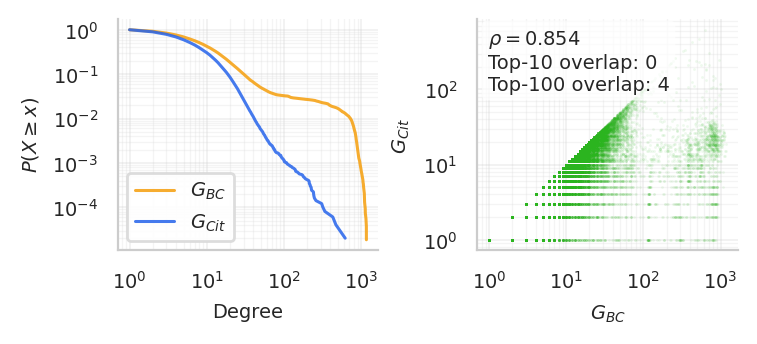

  saved B_centrality_degree.pdf

Betweenness   ρ = 0.794   top-10 overlap = 3/10    top-100 overlap = 44/100


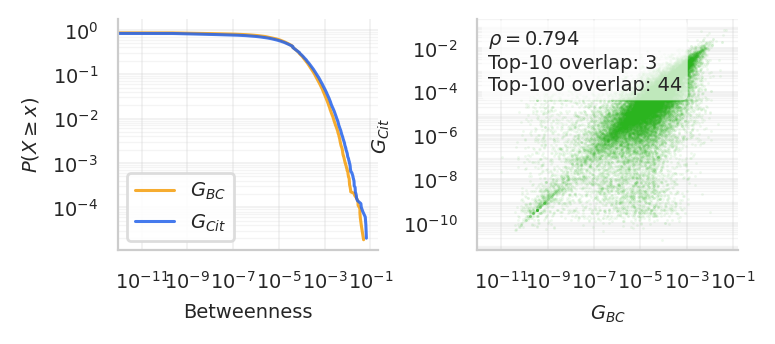

  saved B_centrality_betweenness.pdf

Closeness     ρ = 0.779   top-10 overlap = 1/10    top-100 overlap = 3/100


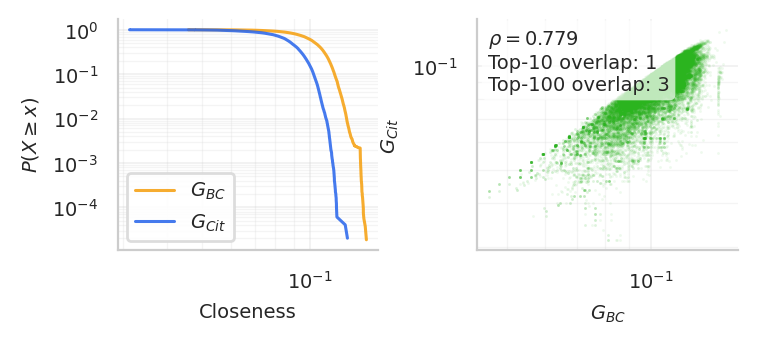

  saved B_centrality_closeness.pdf



In [ ]:
#  Centrality: 3 separate figures (CCDF + scatter) 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from scipy.stats import spearmanr
import numpy as np, os


#  Style 
plt.rcParams.update({
    'figure.dpi': 200,
    'font.size': 7,
    'mathtext.fontset': 'dejavusans',      # math in DejaVu Sans
    'axes.formatter.use_mathtext': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.85',
    'legend.fontsize': 7,
})

C_BC      = '#F59E0B'
C_CIT     = '#2563EB'
C_SCATTER = '#2bb41f'

centralities = [('Degree', deg_c), ('Betweenness', betw), ('Closeness', clos)]


#  Helper 
def polish_logax(ax, which='both'):
    """Tick minori + grid a doppio livello sugli assi log."""
    axes = []
    if which in ('x', 'both'): axes.append(ax.xaxis)
    if which in ('y', 'both'): axes.append(ax.yaxis)

    for axis in axes:
        axis.set_major_locator(LogLocator(base=10, numticks=10))
        axis.set_major_formatter(LogFormatterMathtext(base=10))
        axis.set_minor_locator(LogLocator(base=10, subs='auto', numticks=20))
        axis.set_minor_formatter(mticker.NullFormatter())

    ax.grid(True, which='major', alpha=0.3, lw=0.6, ls='-')
    ax.grid(True, which='minor', alpha=0.2, lw=0.5, ls='-')


#  Loop 
for lbl, src in centralities:
    fig = plt.figure(figsize=(4, 1.5))
    gs  = GridSpec(1, 2, figure=fig, wspace=0.38)

    # shared nodes
    cn   = sorted(set(src['bc']) & set(src['cit']))
    xv   = np.array([src['bc'][n]  for n in cn])
    yv   = np.array([src['cit'][n] for n in cn])
    rho, pval = spearmanr(xv, yv)

    # top-10 overlap
    top10_bc  = set(sorted(src['bc'],  key=src['bc'].__getitem__,  reverse=True)[:10])
    top100_bc = set(sorted(src['bc'],  key=src['bc'].__getitem__,  reverse=True)[:100])
    top10_cit = set(sorted(src['cit'], key=src['cit'].__getitem__, reverse=True)[:10])
    top100_cit = set(sorted(src['cit'], key=src['cit'].__getitem__, reverse=True)[:100])
    overlap   = len(top10_bc & top10_cit)
    print(f"{lbl:12s}  ρ = {rho:.3f}   top-10 overlap = {overlap}/10    top-100 overlap = {len(top100_bc & top100_cit)}/100")

    #  CCDF 
    ax0 = fig.add_subplot(gs[0])
    for k, color, label in [('bc', C_BC, '$G_{BC}$'), ('cit', C_CIT, '$G_{Cit}$')]:
        vals   = np.sort(list(src[k].values()))[::-1]
        x_ccdf = np.sort(np.unique(vals))
        y_ccdf = np.array([np.mean(vals >= v) for v in x_ccdf])
        ax0.loglog(x_ccdf, y_ccdf, color=color, lw=1.1, label=label, alpha=0.85)
    ax0.set_xlabel(lbl)
    ax0.set_ylabel(r'$P(X \geq x)$')
    ax0.legend(loc='lower left')
    polish_logax(ax0)

    #  Scatter 
    ax1 = fig.add_subplot(gs[1])
    ax1.scatter(xv, yv, alpha=0.08, s=1, lw=0, color=C_SCATTER, rasterized=True)
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel(f'$G_{{BC}}$')
    ax1.set_ylabel(f'$G_{{Cit}}$')
    polish_logax(ax1)

    # annotation box
    txt = f'$\\rho = {rho:.3f}$\nTop-10 overlap: {overlap}\nTop-100 overlap: {len(top100_bc & top100_cit)}'
    ax1.text(0.04, 0.96, txt, transform=ax1.transAxes,
         fontsize=7, ha='left', va='top',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.2', lw=0.0, alpha=0.7))
    fname = f'B_centrality_{lbl.lower()}.pdf'
    fig.savefig(os.path.join(out_dir, fname), dpi=250, bbox_inches='tight')
    plt.show()
    print(f"  saved {fname}\n")

## 7 Null-Model Comparison

In [ ]:
rng = np.random.default_rng(42)
N = {k: lcc[k].number_of_nodes() for k in ('bc', 'cit')}
M = {k: lcc[k].number_of_edges() for k in ('bc', 'cit')}
k_avg = {k: 2 * M[k] / N[k] for k in ('bc', 'cit')}

#  Power-law exponent (MLE, Clauset 2009) 
def fit_powerlaw(degrees, k_min=None):
    d = np.array(degrees); d = d[d > 0]
    if k_min is None:
        best_ks, best_km = np.inf, 1
        for km in range(1, min(51, int(np.percentile(d, 90)))):
            tail = d[d >= km]
            if len(tail) < 50: break
            n     = len(tail)
            gamma = 1 + n / np.sum(np.log(tail / (km - 0.5)))
            cdf_emp = np.arange(1, n + 1) / n
            cdf_th  = 1 - (np.sort(tail) / (km - 0.5)) ** (-(gamma - 1))
            ks = np.max(np.abs(cdf_emp - cdf_th))
            if ks < best_ks:
                best_ks, best_km = ks, km
        k_min = best_km
    tail = d[d >= k_min]
    return round(1 + len(tail) / np.sum(np.log(tail / (k_min - 0.5))), 2), k_min

gamma, kmin = {}, {}
for k in ('bc', 'cit'):
    gamma[k], kmin[k] = fit_powerlaw([d for _, d in lcc[k].degree()])
    print(f"  {NAMES[k]}: γ={gamma[k]}, k_min={kmin[k]}")

#  Generate null models 
er, ba, m_ba = {}, {}, {}
for k in ('bc', 'cit'):
    er[k] = nx.gnm_random_graph(N[k], M[k], seed=42)
    m_ba[k] = max(1, round(M[k] / N[k]))
    ba[k] = nx.barabasi_albert_graph(N[k], m_ba[k], seed=42)
    print(f"  {NAMES[k]} — ER: {er[k].number_of_edges():,}  "
          f"BA(m={m_ba[k]}): {ba[k].number_of_edges():,}")

#  Empirical metrics (500-node BFS sample for null models) 
def null_metrics(G, n_samp=500):
    L = G.subgraph(max(nx.connected_components(G), key=len)).copy() if not nx.is_connected(G) else G
    cl = nx.average_clustering(L)
    samp = rng.choice(list(L.nodes()), size=min(n_samp, L.number_of_nodes()), replace=False)
    ds = [d for n in samp for d in nx.single_source_shortest_path_length(L, n).values() if d > 0]
    degs = np.array([d for _, d in G.degree()])
    return {'N': G.number_of_nodes(), 'M': G.number_of_edges(),
            'LCC': L.number_of_nodes(), '⟨k⟩': round(2*L.number_of_edges()/L.number_of_nodes(), 2),
            'γ': '—', 'σ_k': round(float(degs.std()), 2),
            'C_emp': round(cl, 6), 'd_emp': round(float(np.mean(ds)), 2),
            'k_max': int(degs.max())}

print("\nComputing null-model metrics ...")
t0 = time.time()
null_stats = {k: {'ER': null_metrics(er[k]), 'BA': null_metrics(ba[k])} for k in ('bc', 'cit')}
print(f"  Done in {time.time()-t0:.1f}s")

#  Build comparison table (→ Table 4) 
for k in ('bc', 'cit'):
    degs_real = np.array([d for _, d in lcc[k].degree()])
    real = {'N': N[k], 'M': M[k], 'LCC': N[k],
            '⟨k⟩': round(k_avg[k], 2), 'γ': gamma[k],
            'σ_k': round(float(degs_real.std()), 2),
            'C_emp': round(clust[k].mean(), 6),
            'd_emp': round(sp[k]['avg_path'], 2),
            'k_max': int(degs_real.max())}

    # ER theoretical
    p = k_avg[k] / (N[k] - 1)
    null_stats[k]['ER']['C_th'] = round(p, 6)
    null_stats[k]['ER']['d_th'] = round(log(N[k]) / log(k_avg[k]), 2)

    # Small-world σ
    Ce = null_stats[k]['ER']['C_emp']
    Le = null_stats[k]['ER']['d_emp']
    sigma = round((real['C_emp'] / Ce) / (real['d_emp'] / Le), 2) if Ce > 0 else '—'
    real['σ'] = sigma

    print(f"\n{'═'*70}\n{NAMES[k]} LCC vs null models\n{'═'*70}")
    df = pd.DataFrame([{'Model': 'Real', **real},
                       {'Model': 'ER',   **null_stats[k]['ER']},
                       {'Model': 'BA',   **null_stats[k]['BA']}]).set_index('Model')
    print(df.to_string())

  Combined: γ=2.13, k_min=11
  Citation: γ=3.54, k_min=17
  Combined — ER: 739,498  BA(m=14): 747,474
  Citation — ER: 209,599  BA(m=4): 196,956

Computing null-model metrics ...
  Done in 64.2s

══════════════════════════════════════════════════════════════════════
Combined LCC vs null models
══════════════════════════════════════════════════════════════════════
           N       M    LCC    ⟨k⟩     γ     σ_k     C_emp  d_emp  k_max       σ      C_th  d_th
Model                                                                                           
Real   53405  739498  53405  27.69  2.13  103.21  0.425000  10.04   1169  290.97       NaN   NaN
ER     53405  739498  53405  27.69     —    5.24  0.000531   3.65     56     NaN  0.000519  3.28
BA     53405  747474  53405  27.99     —   36.37  0.003715   3.20   1317     NaN       NaN   NaN

══════════════════════════════════════════════════════════════════════
Citation LCC vs null models
═════════════════════════════════════════════════

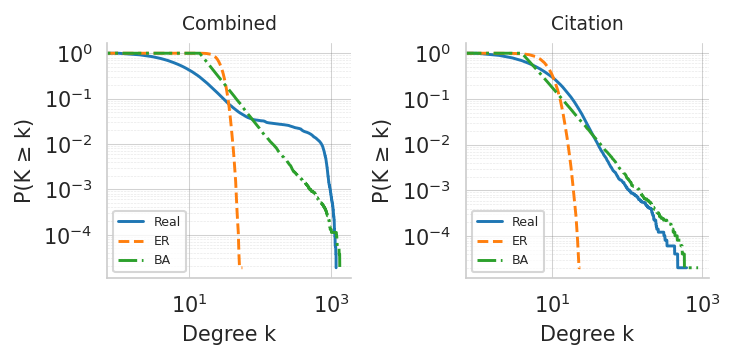

In [ ]:
#  Figure 2: Degree CCDF vs null models 
def degree_ccdf_smooth(G):
    degs = np.array([d for _, d in G.degree()])
    vals = np.arange(0, degs.max() + 1)
    c = np.array([np.mean(degs >= k) for k in vals])
    mask = c > 0
    return vals[mask], c[mask]

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5))
for ax, k in zip(axes, ('bc', 'cit')):
    for G, c, lab, ls in [(lcc[k], 'tab:blue', 'Real', '-'),
                           (er[k],  'tab:orange', 'ER', '--'),
                           (ba[k],  'tab:green',  'BA', '-.')]:
        x, y = degree_ccdf_smooth(G)
        ax.loglog(x, y, color=c, label=lab, lw=1.4, ls=ls)
    ax.set_xlabel('Degree k'); ax.set_ylabel('P(K ≥ k)')
    ax.legend(fontsize=6, loc='lower left')
    ax.set_title(NAMES[k], fontsize=9)
    style_ax(ax, logx=True, logy=True)

plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'degree_ccdf_vs_null.png'), dpi=200, bbox_inches='tight')
plt.show()

## 8 Supplementary Structural Metrics

In [ ]:
#  Assortativity (referenced in §3.6) 
for label, G in [('Combined (uw)', G_combined_uw), ('Citation (ud)', G_cit_ud),
                  ('Citation (dir)', G_cit_d)]:
    r = nx.degree_assortativity_coefficient(G)
    print(f"  {label:<22} r = {r:.4f}")

#  Directed: reciprocity + in/out stats 
recip = nx.reciprocity(G_cit_d)
print(f"\nReciprocity: {recip:.6f}")

in_d  = np.array([d for _, d in G_cit_d.in_degree()])
out_d = np.array([d for _, d in G_cit_d.out_degree()])
df_dir = pd.DataFrame({
    'In-degree':  stat_row(in_d),
    'Out-degree': stat_row(out_d),
}).T
print("\nDirected degree stats:\n", df_dir.to_string(float_format=lambda x: f'{x:.2f}'))

rho_io, _ = spearmanr(in_d, out_d)
print(f"\nSpearman in vs out: ρ = {rho_io:.3f}")

  Combined (uw)          r = 0.8150
  Citation (ud)          r = 0.0552
  Citation (dir)         r = 0.1208

Reciprocity: 0.006892

Directed degree stats:
             Mean  Std  Median    Max   P90   P99
In-degree   3.96 8.58    2.00 616.00 10.00 28.00
Out-degree  3.96 4.82    2.00 128.00 10.00 22.00

Spearman in vs out: ρ = 0.090


In [14]:
del G_combined_w, G_combined_uw, G_cit_d, G_cit_ud
gc.collect()
print("Done — all figures saved to", out_dir)

Done — all figures saved to ./output
